Number of neurons: 639
Creating configuration: 2D_initial_configurations/2D_neurons_params_square_SW_agg_nc10_s0.0300_L3.0_rho71_d0.15.txt
Creating configuration: 2D_created_networks/2D_adjacency_matrix_square_SW_agg_nc10_s0.0300_L3.0_rho71_l1.00_d0.15.txt
[[ 0 11  3 ...  0  0  0]
 [11  0 12 ...  0  0  0]
 [ 8 13  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0 14]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]
Properties of the ADJACENCY MATRIX:
  mean_degree: 33.71478260869565
  clustering_coefficient: 0.6988582478993484
  average_path_length: 3.4202878351764885
  degree_assortativity: 0.14901692440514136
  modularity: 0.7243961845727701
Number of neurons: 575
Excitatory neurons: 460
Inhibitory neurons: 115
Total spikes: 208934
Dynamics saved in: 2D_dynamics/2D_dynamics_square_SW_agg_nc10_s0.0300_L3.0_rho71_l1.00_d0.15_a0.20_exc7.000_sim0.txt




c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Properties of the FUNCTIONAL NETWORK:
  mean_degree: 57.401739130434784
  clustering_coefficient: 0.7313311071390717
  average_path_length: inf
  degree_assortativity: 0.955367035788528
  modularity: 0.686524825944933
(575, 575)
575
0 574
Fuera de plot:
filename_adj = 2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_square_SW_agg_nc10_s0.0300_L3.0_rho71_l1.00_d0.15_a0.20_sim0.txt
A.shape = (575, 575)
len(order) = 575
min(order) = 0
max(order) = 574


c:\Users\Admin\Desktop\Master\TFM\functions_create_networks.py:2827: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


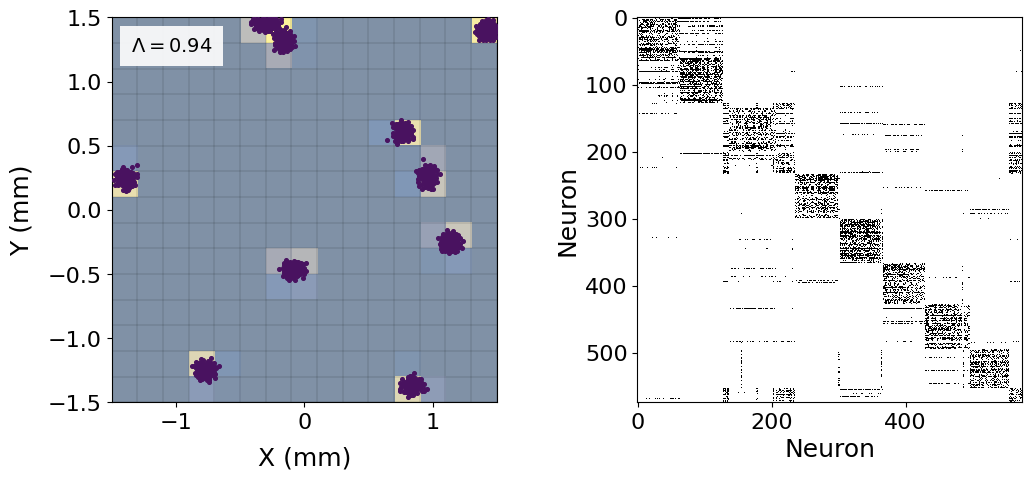

In [15]:
import subprocess
from pathlib import Path
from matplotlib.pylab import seed
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.compile_c_codes()

parameters2D = {
    "L": 3.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
    "rho": 71, # Neuron density (neurons/mm^2)
    "soma_diameter": 0.015, # Diameter of the soma (mm)
    "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
    "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
    "l_mean": 1.0, # Mean axon length (mm) Rayleigh distribution
    "segment_length": 0.01, # Segment length for axon growth (mm)
    "sigma_axon_angle": 0.1, # Standard deviation of the axon angle (radians)
    "agg": 1, # Control parameter for the aggregation of neurons
    "n_centers": 10, # Number of centers for the aggregation of neurons
    "base_sigma": 0.03, # Base standard deviation for aggregation centers (mm)
    "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
    "geometry": "square", # Geometry of the domain (square or circle)
    "seed": 0
}
alpha = 0.2

if parameters2D["geometry"] == "circle" and parameters2D["BC_type"] == "PBC":
    raise ValueError("Periodic Boundary Conditions (PBC) are not compatible with a circular geometry. Please choose 'SW' for BC_type or change the geometry to 'square'.")

if parameters2D["geometry"] == "square" or parameters2D["geometry"] == "squareLongRange":
    N = int(parameters2D["rho"] * parameters2D["L"]**2) # Total number of neurons
elif parameters2D["geometry"] == "circle":
    R = parameters2D["L"] / np.sqrt(np.pi)
    print(f"Effective radius of the circular domain: {R:.2f} mm")
    N = int(parameters2D["rho"] * np.pi * R**2) # Total number of neurons, same as in the square case for the same L, but we keep it here for clarity

# N = int((parameters2D["L"] / parameters2D["soma_diameter"])**2)

print(f"Number of neurons: {N}")
parametersDynamics = {
    "max_exc_weight": 7,
    "max_inh_weight": 0.5,
    "noise_max": 4,
    "sim_time": 20000,
    "seed": 42
}

simulate_dynamics = True
new_sim = True

filename_neuron_params = fcn.run_2D_tune_positions(parameters2D, new_sim=new_sim)
filename_network_tries = fcn.create_network2D(parameters2D, new_sim=new_sim)
M = fcn.load_A(filename_network_tries)
print(M)
A, filename_adj = fcn.modify_A_alpha2D(M, alpha, parameters2D, new_sim=new_sim, GC = True)

propertiesA = fcn.properties_of_network(A)
print("Properties of the ADJACENCY MATRIX:")

for prop, value in propertiesA.items():
    if prop == 'degree_distribution':
        continue
    else:
        print(f"  {prop}: {value}")

order = None

if simulate_dynamics:

    parametersDynamics["out_filename"] = filename_adj
    filename_dynamics = fcn.run_dynamics_2D(
        parametersDynamics,
        parameters2D,
        alpha,
        new_sim=new_sim, 
        show_prints_c = True
    )

    F, F_binary, F_ordered, order_communities, communities = fcn.build_F_matrix(filename_dynamics, parametersDynamics["sim_time"], N = len(A))

    order = order_communities
    
    propertiesF = fcn.properties_of_network(F_binary)
    print("Properties of the FUNCTIONAL NETWORK:")
    for prop, value in propertiesF.items():
        if prop == 'degree_distribution':
            continue
        else:
            print(f"  {prop}: {value}")
    
    print(A.shape)
    print(len(order))
    print(np.min(order), np.max(order))

    print("Fuera de plot:")
    print("filename_adj =", filename_adj)
    print("A.shape =", A.shape)

fcn.plot_spatial_distr_AND_adjacency(filename_neuron_params, A, parameters2D, order = order)

In [16]:
import pandas as pd

input_file = filename_neuron_params
# input_file = "2D_initial_configurations/2D_neurons_params_PBC_random_L2.0_rho150_l1.20_d0.15.txt"
output_file = "nodesagg.csv"

# Leer líneas
with open(input_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Buscar la línea donde empieza la tabla
start_idx = None
for i, line in enumerate(lines):
    if line.strip().startswith("X") and "Y" in line:
        start_idx = i
        break

if start_idx is None:
    raise ValueError("No se encontró la cabecera de la tabla de nodos.")

# Leer tabla desde ahí
from io import StringIO
table_text = "".join(lines[start_idx:])
df = pd.read_csv(StringIO(table_text), sep=r"\s+")

# Añadir columnas para Gephi
df.insert(0, "id", range(len(df)))
df.insert(1, "label", range(len(df)))

# Renombrar columnas
df = df.rename(columns={
    "X": "x",
    "Y": "y",
    "Soma_Diameter": "soma_diameter",
    "Dendrite_Diameter": "dendrite_diameter",
    "Axon_Length": "axon_length"
})

# Guardar
df.to_csv(output_file, index=False)

print(f"Guardado {output_file} con {len(df)} nodos.")

Guardado nodesagg.csv con 639 nodos.


In [17]:
import numpy as np
import pandas as pd

# adj_file = "2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.2000_L3.0_rho250_l0.30_d0.15_a0.20.txt"
edges_file = "edgesagg.csv"

# A = np.loadtxt(adj_file)

sources = []
targets = []
weights = []
types = []

N = A.shape[0]

for i in range(N):
    for j in range(N):
        if A[i, j] != 0:
            sources.append(i)
            targets.append(j)
            weights.append(A[i, j])
            types.append("Directed")   # o "Undirected"

edges_df = pd.DataFrame({
    "source": sources,
    "target": targets,
    "weight": weights,
    "type": types
})

edges_df.to_csv(edges_file, index=False)

print(f"Guardado {edges_file} con {len(edges_df)} enlaces.")

Guardado edgesagg.csv con 19386 enlaces.


Figura guardada en: spatial_graph_curved_dendrites_ran.png


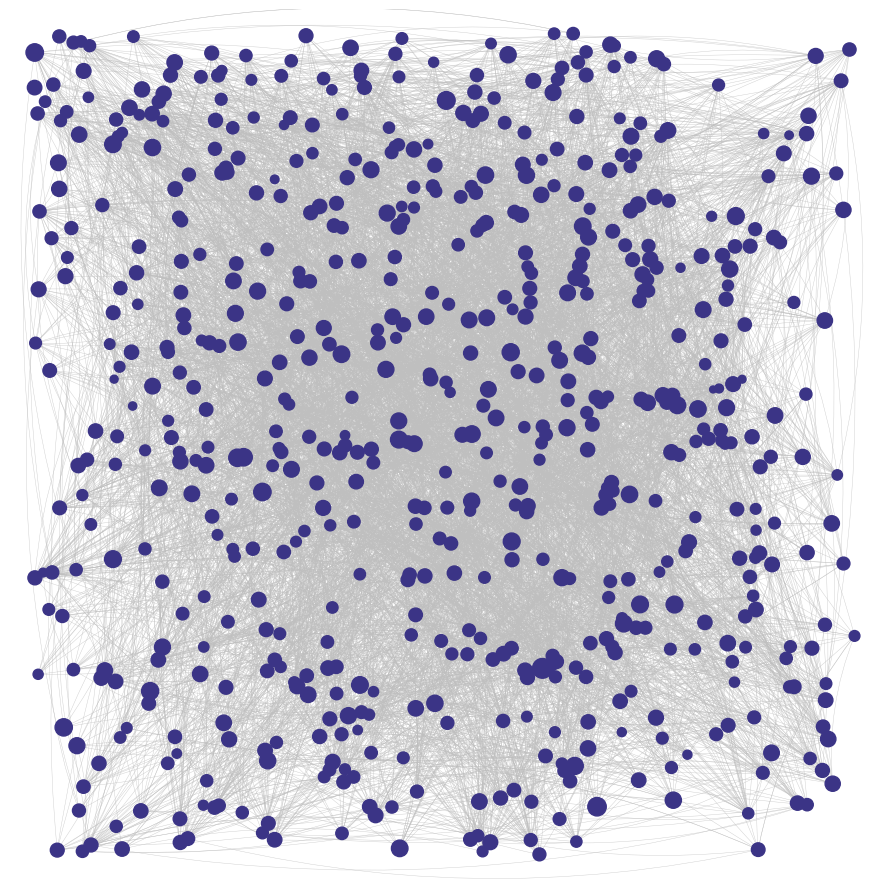

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch


def plot_spatial_graph_curved_dendrites(
    nodes_file,
    edges_file,
    output_file=None,
    figsize=(9, 9),
    node_color="#352a87",
    edge_color="0.75",
    edge_linewidth=0.20,
    edge_alpha=0.15,
    curvature=0.12,
    show_axes=False,
    dpi=400,
    title=None,
    seed=42,
    min_node_size=15,
    max_node_size=140,
    use_raw_diameter=False,
    raw_size_scale=4000
):
    """
    Dibuja un grafo espacial con:
      - posiciones reales x,y
      - aristas curvas
      - tamaño de nodo basado en dendrite_diameter

    Parámetros
    ----------
    nodes_file : str
        CSV de nodos con columnas: id, x, y, dendrite_diameter
    edges_file : str
        CSV de aristas con columnas: source, target
    output_file : str or None
        Archivo de salida para guardar la figura
    figsize : tuple
        Tamaño de la figura
    node_color : str
        Color de los nodos
    edge_color : str
        Color de las aristas
    edge_linewidth : float
        Grosor de las aristas
    edge_alpha : float
        Transparencia de las aristas
    curvature : float
        Curvatura relativa de las aristas
    show_axes : bool
        Mostrar o no los ejes
    dpi : int
        Resolución de guardado
    title : str or None
        Título
    seed : int
        Semilla para el lado de curvatura
    min_node_size : float
        Tamaño mínimo de nodo si se normaliza
    max_node_size : float
        Tamaño máximo de nodo si se normaliza
    use_raw_diameter : bool
        Si True, usa tamaño proporcional al diámetro real al cuadrado
        Si False, normaliza los diámetros para visualización
    raw_size_scale : float
        Factor de escala si use_raw_diameter=True
    """

    rng = np.random.default_rng(seed)

    # -------------------------
    # Leer archivos
    # -------------------------
    nodes = pd.read_csv(nodes_file)
    edges = pd.read_csv(edges_file)

    # -------------------------
    # Comprobaciones
    # -------------------------
    required_node_cols = {"id", "x", "y", "dendrite_diameter"}
    required_edge_cols = {"source", "target"}

    if not required_node_cols.issubset(nodes.columns):
        raise ValueError(
            f"El archivo de nodos debe contener las columnas {required_node_cols}. "
            f"Columnas encontradas: {list(nodes.columns)}"
        )

    if not required_edge_cols.issubset(edges.columns):
        raise ValueError(
            f"El archivo de aristas debe contener las columnas {required_edge_cols}. "
            f"Columnas encontradas: {list(edges.columns)}"
        )

    nodes = nodes.copy()
    edges = edges.copy()

    # Normalizar ids a string para evitar problemas de comparación
    nodes["id"] = nodes["id"].astype(str)
    edges["source"] = edges["source"].astype(str)
    edges["target"] = edges["target"].astype(str)

    # -------------------------
    # Posiciones
    # -------------------------
    pos = dict(zip(nodes["id"], zip(nodes["x"], nodes["y"])))

    # -------------------------
    # Tamaño de nodos a partir del diámetro dendrítico
    # Recordatorio: s en scatter representa área
    # -------------------------
    d = nodes["dendrite_diameter"].to_numpy(dtype=float)

    if np.any(d < 0):
        raise ValueError("Hay valores negativos en dendrite_diameter.")

    if use_raw_diameter:
        # Tamaño proporcional al área ~ diámetro^2
        sizes = raw_size_scale * (d ** 2)
    else:
        # Normalización visual más estable
        if np.allclose(d.max(), d.min()):
            sizes = np.full_like(d, 0.5 * (min_node_size + max_node_size), dtype=float)
        else:
            d_norm = (d - d.min()) / (d.max() - d.min())
            sizes = min_node_size + (max_node_size - min_node_size) * (d_norm ** 2)

    # -------------------------
    # Figura
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # -------------------------
    # Dibujar aristas curvas
    # -------------------------
    missing_nodes = set()

    for _, row in edges.iterrows():
        s = row["source"]
        t = row["target"]

        if s not in pos:
            missing_nodes.add(s)
            continue
        if t not in pos:
            missing_nodes.add(t)
            continue

        x1, y1 = pos[s]
        x2, y2 = pos[t]

        dx = x2 - x1
        dy = y2 - y1
        dist = np.hypot(dx, dy)

        if dist == 0:
            continue

        # Vector perpendicular unitario
        px = -dy / dist
        py = dx / dist

        # Elegimos lado de curvatura
        sign = rng.choice([-1, 1])

        # Punto medio
        mx = 0.5 * (x1 + x2)
        my = 0.5 * (y1 + y2)

        # Punto de control
        cx = mx + sign * curvature * dist * px
        cy = my + sign * curvature * dist * py

        verts = [
            (x1, y1),
            (cx, cy),
            (x2, y2)
        ]

        codes = [
            Path.MOVETO,
            Path.CURVE3,
            Path.CURVE3
        ]

        path = Path(verts, codes)
        patch = PathPatch(
            path,
            facecolor="none",
            edgecolor=edge_color,
            lw=edge_linewidth,
            alpha=edge_alpha,
            zorder=1
        )
        ax.add_patch(patch)

    if missing_nodes:
        print(
            f"Aviso: hay {len(missing_nodes)} nodos referenciados en edges "
            f"que no existen en nodes. Se ignorarán."
        )

    # -------------------------
    # Dibujar nodos
    # -------------------------
    ax.scatter(
        nodes["x"],
        nodes["y"],
        s=sizes,
        c=node_color,
        zorder=2
    )

    # -------------------------
    # Límites
    # -------------------------
    xmin, xmax = nodes["x"].min(), nodes["x"].max()
    ymin, ymax = nodes["y"].min(), nodes["y"].max()

    dx = xmax - xmin
    dy = ymax - ymin
    mx = 0.03 * dx if dx > 0 else 0.1
    my = 0.03 * dy if dy > 0 else 0.1

    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_aspect("equal")

    # -------------------------
    # Título y ejes
    # -------------------------
    if title is not None:
        ax.set_title(title)

    if show_axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()

    # -------------------------
    # Guardar
    # -------------------------
    if output_file is not None:
        plt.savefig(
            output_file,
            dpi=dpi,
            bbox_inches="tight",
            transparent=True
        )
        print(f"Figura guardada en: {output_file}")

    plt.show()


if __name__ == "__main__":
    plot_spatial_graph_curved_dendrites(
        nodes_file="nodesran.csv",
        edges_file="edgesran.csv",
        output_file="spatial_graph_curved_dendrites_ran.png",
        figsize=(9, 9),
        node_color="#3b3486",
        edge_color="0.75",
        edge_linewidth=0.3,
        edge_alpha=0.8,
        curvature=0.12,
        show_axes=False,
        dpi=600,
        title=None,
        seed=42,
        min_node_size=12,
        max_node_size=110,
        use_raw_diameter=True,
        raw_size_scale=4000
    )

In [2]:
import os
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)


from pypalettes import load_cmap
def find_filename2D(parameters2D = None, sigma = 0.5, exc_weight = 8.5, sim_number = 0):

    if parameters2D is None:
        parameters2D = {
            "L": 3.0,
            "rho": 71,
            "soma_diameter": 0.015,
            "d_mean": 0.15,
            "d_sigma": 0.02,
            "l_mean": 1.00,
            "segment_length": 0.01,
            "sigma_axon_angle": 0.1,
            "agg": 1,
            "n_centers": 10,
            "base_sigma": 0.5,
            "BC_type": "SW",
            "geometry": "square"   # "square" or "circle"
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    base_sigma_values = np.linspace(0.03, 0.7, 50)
    MAX_EXC_WEIGHT_values = np.linspace(5, 30.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]


    # ============================================================
    # FILENAMES
    # ============================================================


    filename_adj_2D = (
        f"2D_dynamics/networks_for_dynamics/"
        f"2D_adjacency_matrix_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}"
        f"_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_2D = (
        f"2D_dynamics/2D_dynamics_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    parameters2D["base_sigma"] = base_sigma
    parametersDynamics["max_exc_weight"] = MAX_EXC_WEIGHT
    filename_neuron_params = fcn.run_2D_tune_positions(parameters2D, new_sim=False)

    if not os.path.exists(filename_adj_2D):
        print(f"Archivo no encontrado: {filename_adj_2D}")
    if not os.path.exists(filename_dyn_2D):
        print(f"Archivo no encontrado: {filename_dyn_2D}")
        
    return filename_neuron_params, filename_adj_2D, filename_dyn_2D


def find_filename3D(parameters3D = None, sigma = 0.04, exc_weight = 8.5, sim_number = 0):

    if parameters3D is None:
        parameters3D = {
            "L": 3.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
            "height": 1.0, # Height of the cylinder domain (mm), only used if geometry is "cylinder"
            "rho": 600, # Neuron density (neurons/mm^2)
            "soma_diameter": 0.015, # Diameter of the soma (mm)
            "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
            "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
            "l_mean": 1.00, # Mean axon length (mm) Rayleigh distribution
            "segment_length": 0.01, # Segment length for axon growth (mm)
            "sigma_pol": 0.1, # Standard deviation of the axon angle (radians)
            "sigma_azi": 0.1, # Standard deviation of the azimuthal angle (radians)
            "agg": 1, # Control parameter for the aggregation of neurons
            "n_centers": 80, # Number of centers for the aggregation of neurons
            "base_sigma": 0.04, # Base standard deviation for aggregation centers (mm)
            "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
            "geometry": "cube", # Geometry of the domain (cube or sphere)
            "seed": 0,
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    base_sigma_values = np.linspace(0.03, 0.7, 50)
    MAX_EXC_WEIGHT_values = np.linspace(5, 30.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    sunset2 = load_cmap("Sunset2", cmap_type="continuous")

    # ============================================================
    # FILENAMES
    # ============================================================

    filename_adj_3D = (
        f"3D_dynamics/networks_for_dynamics/"
        f"3D_adjacency_matrix_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_3D = (
        f"3D_dynamics/3D_dynamics_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado: {filename_adj_3D}")
    if not os.path.exists(filename_dyn_3D):
        print(f"Archivo no encontrado: {filename_dyn_3D}")
    return filename_adj_3D, filename_dyn_3D

def compute_roc(A, F):

    # -------------------------
    # Simetrizar estructura
    # -------------------------
    F = np.nan_to_num(F, nan=0.0)

    A = ((A + A.T) > 0).astype(int)

    # -------------------------
    # Score funcional
    # -------------------------

    F = np.abs(F)

    # -------------------------
    # Triángulo superior
    # -------------------------

    mask = np.triu(np.ones(A.shape, dtype=bool), k=1)

    y_true = A[mask]
    y_score = F[mask]

    # -------------------------
    # ROC
    # -------------------------

    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc, thresholds

import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

def get_threshold_at_target_fpr(fpr, thresholds, target_fpr=0.1):
    order = np.argsort(fpr)
    fpr_sorted = fpr[order]
    thresholds_sorted = thresholds[order]

    threshold = np.interp(target_fpr, fpr_sorted, thresholds_sorted)

    return threshold

sigma_2D_1 = 0.7
exc_weight_2D_1 = 15

sigma_2D_2 = 0.04
exc_weight_2D_2 = 15

sigma_3D_1 = 0.7
exc_weight_3D_1 = 23

sigma_3D_2 = 0.03
exc_weight_3D_2 = 10




base_sigma = 0.10
exc_weight = 15
sim = 6
target_fpr = 0.1

filename_neuron_params, filename_adj, filename_dyn = find_filename2D(
    sigma=base_sigma,
    exc_weight=exc_weight,
    sim_number=sim
)

firings_t, firings_i = fcn.load_firings(filename_dyn)

A = fcn.load_A(filename_adj)
N = A.shape[0]

F = fcn.build_F_for_roc(
    filename_dyn,
    SIM_TIME=10000,
    N=N
)

fpr, tpr, roc_auc, thresholds = compute_roc(A, F)

threshold_at_fpr01 = get_threshold_at_target_fpr(
    fpr,
    thresholds,
    target_fpr=target_fpr
)

F, F_binary, F_ordered, order, communities = fcn.build_F_matrix(
    filename_dyn,
    SIM_TIME=10000,
    N=N,
    threshold=threshold_at_fpr01
)

pos_xy = np.loadtxt(filename_neuron_params, skiprows=1, usecols=(0, 1))
print("pos_xy shape:", pos_xy.shape)


Configuration already exists: 2D_initial_configurations/2D_neurons_params_square_SW_agg_nc10_s0.0984_L3.0_rho71_d0.15.txt
pos_xy shape: (639, 2)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def export_to_gephi(A, F_binary, communities, filename="network_tp_fp_fn.gexf"):
    N = A.shape[0]
    np.fill_diagonal(A, 0)
    np.fill_diagonal(F_binary, 0)

    TP_mask = (A == 1) & (F_binary == 1)
    FP_mask = (A == 0) & (F_binary == 1)
    FN_mask = (A == 1) & (F_binary == 0)

    # Comunidad de cada nodo
    if isinstance(communities[0], (set, frozenset)):
        node_community = {}
        for k, s in enumerate(communities):
            for node in s:
                node_community[node] = k
    else:
        node_community = {i: int(communities[i]) for i in range(N)}

    colors = {
        "TP": ("46",  "204", "113"),
        "FP": ("231", "76",  "60"),
        "FN": ("230", "126", "34"),
    }

    # Colores por comunidad (tab20)
    cmap = plt.cm.get_cmap("tab20", len(set(node_community.values())))
    def comm_color(k):
        r, g, b, _ = cmap(k)
        return str(int(r*255)), str(int(g*255)), str(int(b*255))

    lines = []
    lines.append('<?xml version="1.0" encoding="UTF-8"?>')
    lines.append('<gexf xmlns="http://gexf.net/1.3"')
    lines.append('      xmlns:viz="http://gexf.net/1.3/viz"')
    lines.append('      version="1.3">')
    lines.append('  <graph defaultedgetype="directed">')

    # Atributos de nodo
    lines.append('    <attributes class="node">')
    lines.append('      <attribute id="0" title="community" type="integer"/>')
    lines.append('    </attributes>')

    # Atributos de arista
    lines.append('    <attributes class="edge">')
    lines.append('      <attribute id="0" title="edge_type" type="string"/>')
    lines.append('    </attributes>')

    # Nodos
    lines.append('    <nodes>')
    for i in range(N):
        k = node_community[i]
        r, g, b = comm_color(k)
        lines.append(f'      <node id="{i}" label="N{i}">')
        lines.append(f'        <attvalues><attvalue for="0" value="{k}"/></attvalues>')
        lines.append(f'        <viz:color r="{r}" g="{g}" b="{b}" a="1.0"/>')
        lines.append(f'        <viz:size value="3"/>')
        lines.append(f'      </node>')
    lines.append('    </nodes>')

    # Aristas
    lines.append('    <edges>')
    edge_id = 0
    for mask, etype in [(TP_mask, "TP"), (FP_mask, "FP"), (FN_mask, "FN")]:
        r, g, b = colors[etype]
        rows, cols = np.where(mask)
        for i, j in zip(rows, cols):
            lines.append(f'      <edge id="{edge_id}" source="{i}" target="{j}">')
            lines.append(f'        <attvalues><attvalue for="0" value="{etype}"/></attvalues>')
            lines.append(f'        <viz:color r="{r}" g="{g}" b="{b}" a="0.6"/>')
            lines.append(f'      </edge>')
            edge_id += 1
    lines.append('    </edges>')

    lines.append('  </graph>')
    lines.append('</gexf>')

    with open(filename, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"Exportado: {filename}")
    print(f"Nodos: {N} | TP: {TP_mask.sum()} | FP: {FP_mask.sum()} | FN: {FN_mask.sum()}")

export_to_gephi(A, F_binary, communities, filename="network_tp_fp_fn.gexf")

C:\Users\Admin\AppData\Local\Temp\ipykernel_19536\3164725373.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(set(node_community.values())))


Exportado: network_tp_fp_fn.gexf
Nodos: 631 | TP: 8979 | FP: 43001 | FN: 5997


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pypalettes import load_cmap
viridis = load_cmap("viridis", cmap_type="continuous")  


def plot_circular_tp_fp_fn(
    A,
    F_binary,
    communities,
    community_to_plot="all",   # "all", "largest", o índice: 0, 1, 2...
    frac_tp=0.3,
    frac_fp=0.03,
    frac_fn=0.3,
    lw=0.4,
    node_size=8,
    edge_alpha_tp=0.5,
    edge_alpha_fp=0.3,
    edge_alpha_fn=0.35,
    seed=42,
    figsize=(10, 10),
    title="Structural vs Functional network",
    show_legend=True,
):
    rng = np.random.default_rng(seed)

    A = A.copy()
    F_binary = F_binary.copy()

    np.fill_diagonal(A, 0)
    np.fill_diagonal(F_binary, 0)

    N = A.shape[0]

    # ============================================================
    # Comunidades
    # ============================================================

    if isinstance(communities[0], (set, frozenset)):
        comm_list = [sorted(c) for c in communities]
    else:
        comm_dict = {}
        for node, comm in enumerate(communities):
            comm_dict.setdefault(comm, []).append(node)
        comm_list = list(comm_dict.values())

    comm_list = sorted(comm_list, key=len, reverse=True)

    # ============================================================
    # Elegir nodos a plotear
    # ============================================================

    if community_to_plot == "all":
        selected_nodes = [node for comm in comm_list for node in comm]
        selected_comm_list = comm_list

    elif community_to_plot == "largest":
        selected_nodes = comm_list[0]
        selected_comm_list = [comm_list[0]]

    elif isinstance(community_to_plot, int):
        selected_nodes = comm_list[community_to_plot]
        selected_comm_list = [comm_list[community_to_plot]]

    else:
        raise ValueError(
            "community_to_plot debe ser 'all', 'largest' o un índice entero."
        )

    selected_nodes = np.array(selected_nodes, dtype=int)
    n_sel = len(selected_nodes)

    # Submatrices restringidas a los nodos seleccionados
    A_sel = A[np.ix_(selected_nodes, selected_nodes)]
    F_sel = F_binary[np.ix_(selected_nodes, selected_nodes)]

    # ============================================================
    # Posiciones circulares
    # ============================================================

    angles = np.linspace(0, 2 * np.pi, n_sel, endpoint=False)
    pos = np.column_stack([np.cos(angles), np.sin(angles)])

    # ============================================================
    # Colores de nodos
    # ============================================================

    cmap_comm = plt.cm.get_cmap("tab20", len(comm_list))
    node_colors = np.zeros((n_sel, 4))

    if community_to_plot == "all":
        node_to_local = {node: i for i, node in enumerate(selected_nodes)}

        for k, comm in enumerate(comm_list):
            for node in comm:
                if node in node_to_local:
                    node_colors[node_to_local[node]] = cmap_comm(k)
    else:
        node_colors[:] = cmap_comm(0)

    # ============================================================
    # TP / FP / FN
    # ============================================================

    TP_mask = (A_sel == 1) & (F_sel == 1)
    FP_mask = (A_sel == 0) & (F_sel == 1)
    FN_mask = (A_sel == 1) & (F_sel == 0)

    def get_edges(mask):
        rows, cols = np.where(mask)
        return list(zip(rows.tolist(), cols.tolist()))

    def subsample(edges, frac):
        if len(edges) == 0:
            return []
        n = max(1, int(len(edges) * frac))
        idx = rng.choice(len(edges), size=n, replace=False)
        return [edges[i] for i in idx]

    tp_edges = subsample(get_edges(TP_mask), frac_tp)
    fp_edges = subsample(get_edges(FP_mask), frac_fp)
    fn_edges = subsample(get_edges(FN_mask), frac_fn)
#010101FF, #69B3E7FF, #BA0C2FFF
#004488FF, #DDAA33FF, #BB5566FF
#D01556FF, #EFDC60FF, #7CCA89FF
    color_tp = "#7CCA89FF"
    color_fp = "#D01556FF"
    color_fn = "#004488FF"

    # ============================================================
    # Plot
    # ============================================================

    fig, ax = plt.subplots(figsize=figsize)

    def draw_edges(edges, color, alpha):
        for i, j in edges:
            ax.plot(
                [pos[i, 0], pos[j, 0]],
                [pos[i, 1], pos[j, 1]],
                color=color,
                alpha=alpha,
                lw=lw,
                zorder=1,
                solid_capstyle="round",
            )

    draw_edges(fn_edges, color_fn, edge_alpha_fn)
    draw_edges(fp_edges, color_fp, edge_alpha_fp)
    draw_edges(tp_edges, color_tp, edge_alpha_tp)

    ax.scatter(
        pos[:, 0],
        pos[:, 1],
        s=node_size,
        c=viridis(0.1),
        zorder=3,
    )

    if show_legend:
        legend_handles = [
            mlines.Line2D(
                [], [], color=color_tp, lw=3,
                label=f"TP"
            ),
            mlines.Line2D(
                [], [], color=color_fp, lw=3,
                label=f"FP"
            ),
            mlines.Line2D(
                [], [], color=color_fn, lw=3,
                label=f"FN"
            ),
        ]

        ax.legend(
            handles=legend_handles,
            fontsize=26,
            loc="upper left",
            framealpha=0.8,
            frameon = False
        )

    ax.set_title(title, fontsize=16)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()

    return fig, ax

C:\Users\Admin\AppData\Local\Temp\ipykernel_46084\4169691425.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_comm = plt.cm.get_cmap("tab20", len(comm_list))
C:\Users\Admin\AppData\Local\Temp\ipykernel_46084\4169691425.py:153: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


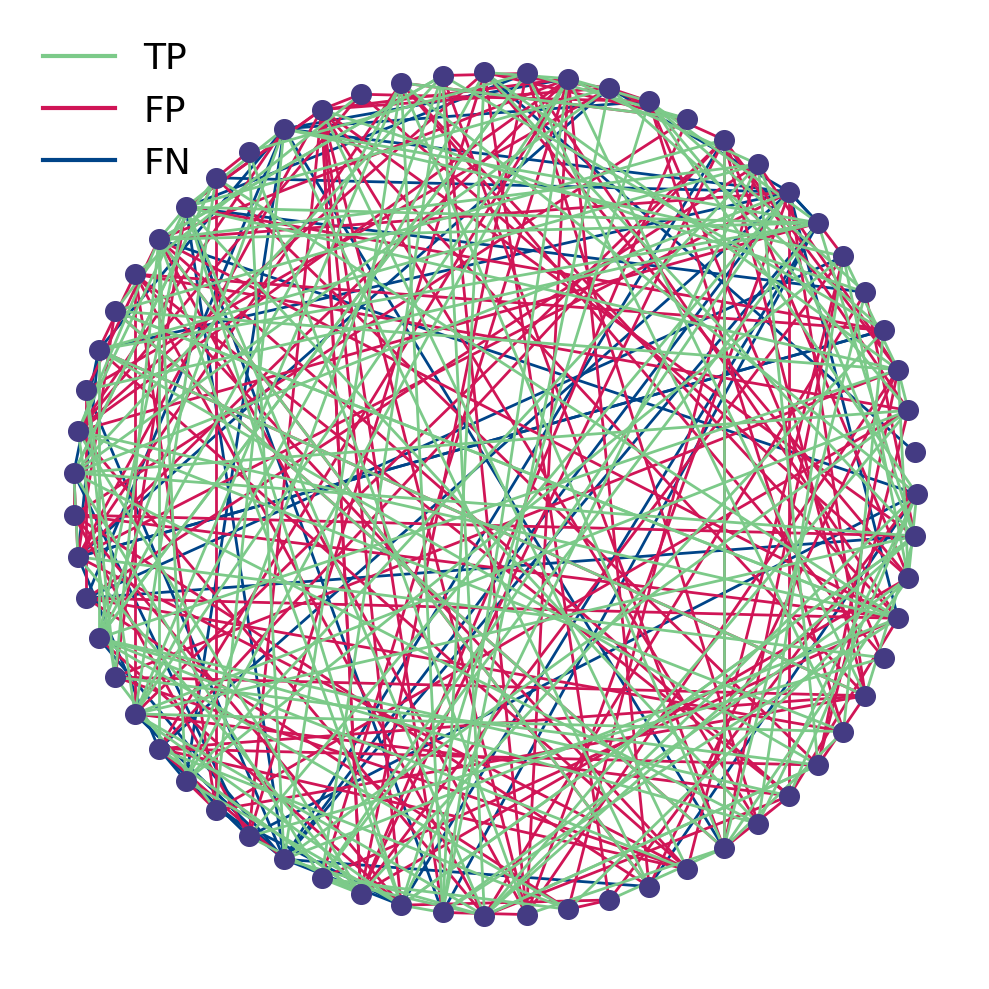

In [8]:
fig, ax = plot_circular_tp_fp_fn(
    A=A,
    F_binary=F_binary,
    communities=communities,
    community_to_plot=3,
    frac_tp=0.2,
    frac_fp=0.05,
    frac_fn=1,
    lw=2.,
    node_size=200,
    edge_alpha_tp=1,
    edge_alpha_fp=1,
    edge_alpha_fn=1,
    title="", 
    show_legend=True
)

plt.savefig("figures_TFM/circular_largest_community_tp_fp_fn.png",
            dpi=600, bbox_inches="tight", transparent=True)
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from pypalettes import load_cmap

viridis = load_cmap("viridis", cmap_type="continuous")


def plot_circular_tp_fp_fn(
    A,
    F_binary,
    communities,
    community_to_plot="all",   # "all", "largest", o índice: 0, 1, 2...
    frac_tp=0.3,
    frac_fp=0.03,
    frac_fn=0.3,
    lw=0.4,
    node_size=8,
    edge_alpha_tp=0.5,
    edge_alpha_fp=0.3,
    edge_alpha_fn=0.35,
    curvature=0.18,
    seed=42,
    figsize=(10, 10),
    title="Structural vs Functional network",
    show_legend=True,
):
    rng = np.random.default_rng(seed)

    A = A.copy()
    F_binary = F_binary.copy()

    np.fill_diagonal(A, 0)
    np.fill_diagonal(F_binary, 0)

    N = A.shape[0]

    # ============================================================
    # Comunidades
    # ============================================================

    if isinstance(communities[0], (set, frozenset)):
        comm_list = [sorted(c) for c in communities]
    else:
        comm_dict = {}
        for node, comm in enumerate(communities):
            comm_dict.setdefault(comm, []).append(node)
        comm_list = list(comm_dict.values())

    comm_list = sorted(comm_list, key=len, reverse=True)

    # ============================================================
    # Elegir nodos a plotear
    # ============================================================

    if community_to_plot == "all":
        selected_nodes = [node for comm in comm_list for node in comm]
        selected_comm_list = comm_list

    elif community_to_plot == "largest":
        selected_nodes = comm_list[0]
        selected_comm_list = [comm_list[0]]

    elif isinstance(community_to_plot, int):
        selected_nodes = comm_list[community_to_plot]
        selected_comm_list = [comm_list[community_to_plot]]

    else:
        raise ValueError(
            "community_to_plot debe ser 'all', 'largest' o un índice entero."
        )

    selected_nodes = np.array(selected_nodes, dtype=int)
    n_sel = len(selected_nodes)

    A_sel = A[np.ix_(selected_nodes, selected_nodes)]
    F_sel = F_binary[np.ix_(selected_nodes, selected_nodes)]

    # ============================================================
    # Posiciones circulares
    # ============================================================

    angles = np.linspace(0, 2 * np.pi, n_sel, endpoint=False)
    pos = np.column_stack([np.cos(angles), np.sin(angles)])

    # ============================================================
    # Colores de nodos
    # ============================================================

    cmap_comm = plt.cm.get_cmap("tab20", len(comm_list))
    node_colors = np.zeros((n_sel, 4))

    if community_to_plot == "all":
        node_to_local = {node: i for i, node in enumerate(selected_nodes)}

        for k, comm in enumerate(comm_list):
            for node in comm:
                if node in node_to_local:
                    node_colors[node_to_local[node]] = cmap_comm(k)
    else:
        node_colors[:] = cmap_comm(0)

    # ============================================================
    # TP / FP / FN
    # ============================================================

    TP_mask = (A_sel == 1) & (F_sel == 1)
    FP_mask = (A_sel == 0) & (F_sel == 1)
    FN_mask = (A_sel == 1) & (F_sel == 0)

    def get_edges(mask):
        rows, cols = np.where(mask)
        return list(zip(rows.tolist(), cols.tolist()))

    def subsample(edges, frac):
        if len(edges) == 0:
            return []
        n = max(1, int(len(edges) * frac))
        idx = rng.choice(len(edges), size=n, replace=False)
        return [edges[i] for i in idx]

    tp_edges = subsample(get_edges(TP_mask), frac_tp)
    fp_edges = subsample(get_edges(FP_mask), frac_fp)
    fn_edges = subsample(get_edges(FN_mask), frac_fn)

    color_tp = "#7CCA89FF"
    color_fp = "#D01556FF"
    color_fn = "#004488FF"

    # ============================================================
    # Plot
    # ============================================================

    fig, ax = plt.subplots(figsize=figsize)

    def draw_edges(edges, color, alpha):
        for i, j in edges:
            p0 = pos[i]
            p1 = pos[j]

            direction = p1 - p0
            dist = np.linalg.norm(direction)

            if dist == 0:
                continue

            mid = 0.5 * (p0 + p1)

            perp = np.array([-direction[1], direction[0]])
            perp = perp / np.linalg.norm(perp)

            control = mid + curvature * dist * perp

            path = Path(
                [p0, control, p1],
                [Path.MOVETO, Path.CURVE3, Path.CURVE3]
            )

            patch = PathPatch(
                path,
                facecolor="none",
                edgecolor=color,
                lw=lw,
                alpha=alpha,
                zorder=1,
                capstyle="round"
            )

            ax.add_patch(patch)

    draw_edges(fn_edges, color_fn, edge_alpha_fn)
    draw_edges(fp_edges, color_fp, edge_alpha_fp)
    draw_edges(tp_edges, color_tp, edge_alpha_tp)

    ax.scatter(
        pos[:, 0],
        pos[:, 1],
        s=node_size,
        c=viridis(0.1),
        zorder=3,
    )

    if show_legend:
        legend_handles = [
            mlines.Line2D([], [], color=color_tp, lw=3, label="TP"),
            mlines.Line2D([], [], color=color_fp, lw=3, label="FP"),
            mlines.Line2D([], [], color=color_fn, lw=3, label="FN"),
        ]

        ax.legend(
            handles=legend_handles,
            fontsize=26,
            loc="upper left",
            framealpha=0.8,
            frameon=False
        )

    ax.set_title(title, fontsize=16)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig("figures_TFM/circular_largest_community_tp_fp_fn_curved.png",
                dpi=600, bbox_inches="tight", transparent=True)
    plt.show()
    return fig, ax

C:\Users\Admin\AppData\Local\Temp\ipykernel_46084\3370912644.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_comm = plt.cm.get_cmap("tab20", len(comm_list))
C:\Users\Admin\AppData\Local\Temp\ipykernel_46084\3370912644.py:177: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


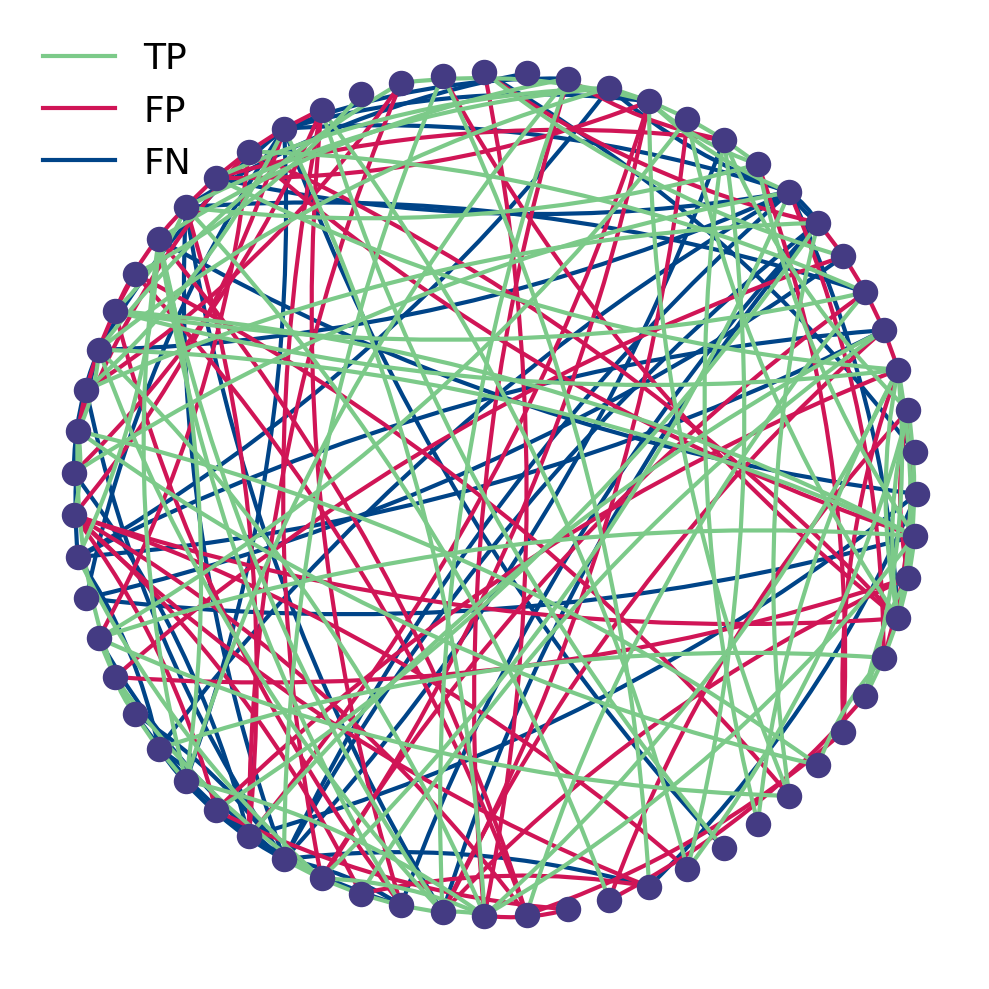

In [24]:
fig, ax = plot_circular_tp_fp_fn(
    A=A,
    F_binary=F_binary,
    communities=communities,
    community_to_plot=3,
    frac_tp=0.1,
    frac_fp=0.02,
    frac_fn=1,
    lw=3.,
    node_size=300,
    edge_alpha_tp=1,
    edge_alpha_fp=1,
    edge_alpha_fn=1,
    title="", 
    show_legend=True,
    curvature=0.1,   # Casi rectas
)